# Online Retail Business EDA
## 온라인 리테일 비즈니스 EDA

---

### Project Goal

**English**

This exploratory analysis aims to identify business growth opportunities for an online retail company.
The notebook is designed to answer several business questions **before** implementing the production pipeline.

**한국어**

이 노트북은 온라인 리테일 기업의 성장 기회를 찾기 위한 탐색적 데이터 분석(EDA)입니다.
실제 Pipeline을 구현하기 전에 데이터를 이해하고, 필요한 전처리를 결정하기 위한 목적입니다.

> **Note:** This notebook is NOT the final implementation.
> All validated logic will be moved into the `pipeline/` package later.
> 이 노트북은 최종 구현이 아닙니다. 검증된 로직은 나중에 `pipeline/` 패키지로 이동됩니다.

---
## Workflow
## 분석 흐름

**English**

Each business question follows the same structured workflow to ensure consistent and well-documented analysis.

**한국어**

각 비즈니스 질문은 일관성 있고 체계적인 분석을 위해 동일한 흐름을 따릅니다.

```
Business Question       비즈니스 질문 정의
        ↓
Relevant Columns        관련 컬럼 파악
        ↓
EDA                     탐색적 데이터 분석
        ↓
Observations            관찰 결과 기록
        ↓
Cleaning Decisions      전처리 결정
        ↓
Implement in Pipeline   Pipeline에 구현
```

---
## 1. Import Libraries
## 라이브러리 불러오기

**English**

Import the core libraries used throughout this notebook.

**한국어**

이 노트북 전반에서 사용하는 핵심 라이브러리를 불러옵니다.

| Library | Purpose | 용도 |
|---------|---------|------|
| `pandas` | Data manipulation and analysis | 데이터 조작 및 분석 |
| `numpy` | Numerical operations | 수치 연산 |
| `matplotlib.pyplot` | Static charts and plots | 정적 차트 |
| `seaborn` | Statistical visualisation | 통계 시각화 |
| `plotly.express` | Interactive charts | 인터랙티브 차트 |

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings (출력 설정)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 2. Load Dataset
## 데이터 불러오기

**English**

Load the Online Retail dataset from the `data/` folder.

**한국어**

`data/` 폴더에서 Online Retail 데이터셋을 불러옵니다.

In [123]:
df_raw = pd.read_excel("../data/online_retail.xlsx")
print(f"Dataset loaded: {len(df_raw):,} rows, {df_raw.shape[1]} columns")

Dataset loaded: 541,909 rows, 8 columns


### 2-1. First Rows — `head()`
**English** Check that the data loaded correctly and that column names make sense.  
**한국어** 데이터가 정상적으로 로드됐는지, 컬럼명이 올바른지 확인한다.

In [124]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


### 2-2. Shape — `shape`
**English** Get the total number of rows and columns.  
**한국어** 전체 행과 컬럼 수를 확인한다.

In [125]:
print(f"Rows   (행): {df_raw.shape[0]:,}")
print(f"Columns (열): {df_raw.shape[1]}")

Rows   (행): 541,909
Columns (열): 8


### 2-3. Data Types — `info()`
**English** Check whether data types are appropriate (e.g. dates should be datetime, not object).  
**한국어** 데이터 타입이 올바른지 확인한다. (날짜는 datetime이어야 함)

In [126]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


### 2-4. Descriptive Statistics — `describe()`
**English** Check the distribution of numeric columns — look for unexpected min/max values.  
**한국어** 수치 컬럼의 분포를 확인한다. 예상치 못한 min/max 값이 있는지 본다.

In [127]:
df_raw.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,"541,909.00",541909,540455,"541,909.00",541909,"541,909.00","406,829.00",541909
unique,"25,900.00",4070,4223,NaN,NaN,NaN,NaN,38
top,"573,585.00",85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,"1,114.00",2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69",NaN
min,NaN,NaN,NaN,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00",NaN
25%,NaN,NaN,NaN,1.00,2011-03-28 11:34:00,1.25,"13,953.00",NaN
50%,NaN,NaN,NaN,3.00,2011-07-19 17:17:00,2.08,"15,152.00",NaN
75%,NaN,NaN,NaN,10.00,2011-10-19 11:27:00,4.13,"16,791.00",NaN
max,NaN,NaN,NaN,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00",NaN


### 2-5. Missing Values
**English** Identify which columns have missing values and how many.  
**한국어** 어떤 컬럼에 결측값이 있고 얼마나 많은지 확인한다.

In [128]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Missing Count (결측 수)": missing, "Missing % (결측 비율)": missing_pct})

,Missing Count (결측 수),Missing % (결측 비율)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


---
## 3. Quick Dataset Overview
## 전체 데이터 빠르게 살펴보기

**English**

A lightweight pass over the full dataset to spot obvious issues.
This is NOT deep cleaning — just orientation.

**한국어**

전체 데이터를 가볍게 훑어보며 명확한 문제를 파악한다.
깊은 전처리가 아닌, 방향을 잡기 위한 단계다.

#### Duplicate Rows (중복 행)

In [129]:
duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows (중복 행): {duplicates:,}")

Duplicate rows (중복 행): 5,268


#### Numeric Columns (수치 컬럼)

In [130]:
df_raw.select_dtypes(include='number').columns.tolist()

['Quantity', 'UnitPrice', 'CustomerID']

#### Categorical Columns (범주형 컬럼)

In [131]:
df_raw.select_dtypes(include='object').columns.tolist()

/var/folders/9d/hwl9yp1n3rv1y9j90spl8rmh0000gn/T/ipykernel_2203/1765358109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.select_dtypes(include='object').columns.tolist()


['InvoiceNo', 'StockCode', 'Description', 'Country']

#### Date Range (데이터 기간)

In [132]:
print(f"Start (시작): {df_raw['InvoiceDate'].min()}")
print(f"End   (종료): {df_raw['InvoiceDate'].max()}")

Start (시작): 2010-12-01 08:26:00
End   (종료): 2011-12-09 12:50:00


---
## 4. Business Question 1 — Market Analysis
## 시장 분석

### Business Question
**English:** Which countries generate the most revenue, and what does the market look like excluding the UK?  
**한국어:** 어떤 국가가 가장 많은 매출을 발생시키며, 영국을 제외하면 어떤 시장이 성장 가능성이 있는가?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `Country` | Segment revenue by market | 시장별 매출 분류 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 4-1. Country — unique values and distribution
**한국어** 국가 unique 값 및 분포 확인

In [133]:
# ==========================================================
# Country — Unique Values and Distribution
# 국가 unique 값 및 분포 확인
# ==========================================================

# 1. Basic Statistics
# 기본 통계
country_count = df_raw["Country"].value_counts()
country_count_pct = (country_count / len(df_raw) * 100).round(2)

print(f"Unique countries (고유 국가): {df_raw['Country'].nunique()}")
display(pd.DataFrame({
    "Count (빈도)": country_count,
    "Count % (빈도 비율)": country_count_pct,
}))

# Note: United Kingdom accounts for ~91.43% of transactions
# 참고: United Kingdom이 전체 거래의 약 91.43%를 차지함


Unique countries (고유 국가): 38


,Count (빈도),Count % (빈도 비율)
Country,,
United Kingdom,495478,91.43
Germany,9495,1.75
France,8557,1.58
EIRE,8196,1.51
Spain,2533,0.47
Netherlands,2371,0.44
Belgium,2069,0.38
Switzerland,2002,0.37
Portugal,1519,0.28


In [134]:
# ==========================================================
# Rename Country Labels
# 국가명 변경
# ==========================================================

# EIRE → Ireland, RSA → Republic of South Africa
rename_countries = {
    "EIRE": "Ireland",
    "RSA": "Republic of South Africa",
}

df_raw["Country"] = df_raw["Country"].replace(rename_countries)


In [135]:
# ==========================================================
# Exclude Ambiguous Countries
# 애매한 국가 제외
# ==========================================================

# Remove Unspecified, European Community
exclude_countries = ["Unspecified", "European Community"]
df_raw = df_raw[~df_raw["Country"].isin(exclude_countries)]

print(f"Excluded countries (제외된 국가): {exclude_countries}")
print(f"Remaining rows (남은 행): {len(df_raw):,}")


Excluded countries (제외된 국가): ['Unspecified', 'European Community']
Remaining rows (남은 행): 541,402


In [136]:
# ==========================================================
# Country Distribution Excluding UK
# UK 제외 국가 분포
# ==========================================================

country_count_without_uk = (
    df_raw[df_raw["Country"] != "United Kingdom"]["Country"]
    .value_counts()
)
country_count_without_uk_pct = (
    country_count_without_uk
    / len(df_raw[df_raw["Country"] != "United Kingdom"])
    * 100
).round(2)

print("Sales frequency by country — excluding UK (UK 제외 국가별 판매 빈도)")
display(pd.DataFrame({
    "Count (빈도)": country_count_without_uk,
    "Count % (빈도 비율)": country_count_without_uk_pct,
}))


Sales frequency by country — excluding UK (UK 제외 국가별 판매 빈도)


,Count (빈도),Count % (빈도 비율)
Country,,
Germany,9495,20.68
France,8557,18.63
Ireland,8196,17.85
Spain,2533,5.52
Netherlands,2371,5.16
Belgium,2069,4.51
Switzerland,2002,4.36
Portugal,1519,3.31
Australia,1259,2.74


#### 4-2. Negative or zero Quantity
**한국어** Quantity 음수/0 여부 확인

In [137]:
# ==========================================================
# Negative Quantity Investigation
# Quantity 음수 데이터 조사
# ==========================================================

# 1. Basic Statistics
# 기본 통계
negative_quantity = df_raw[df_raw["Quantity"] <= 0]

negative_count = len(negative_quantity)
negative_pct = negative_count / len(df_raw) * 100

print(f"Negative Quantity Rows : {negative_count:,} ({negative_pct:.2f}%)")

display(negative_quantity.head())

Negative Quantity Rows : 10,623 (1.96%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,"14,527.00",United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom


In [138]:
# ==========================================================
# Compare Negative Quantity vs Cancelled Invoice
# 음수 Quantity와 취소 주문 비교
# ==========================================================

is_negative = df_raw["Quantity"] <= 0
is_cancelled = df_raw["InvoiceNo"].astype(str).str.startswith("C")

print(f"Negative Quantity         : {is_negative.sum():,}")
print(f"Cancelled Invoice (C)     : {is_cancelled.sum():,}")
print(f"Overlap                   : {(is_negative & is_cancelled).sum():,}")
print(f"Negative Only             : {(is_negative & ~is_cancelled).sum():,}")
print(f"Cancelled Only            : {(~is_negative & is_cancelled).sum():,}")

Negative Quantity         : 10,623
Cancelled Invoice (C)     : 9,287
Overlap                   : 9,287
Negative Only             : 1,336
Cancelled Only            : 0


In [139]:
# ==========================================================
# Investigate Negative Quantity without Cancelled Invoice
# C Invoice가 아닌 음수 Quantity 조사
# ==========================================================

negative_only = df_raw[is_negative & ~is_cancelled]

display(
    negative_only[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "CustomerID",
        ]
    ]
)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
2406,536589,21777,NaN,-10,0.00,NaN
4347,536764,84952C,NaN,-38,0.00,NaN
7188,536996,22712,NaN,-20,0.00,NaN
7189,536997,22028,NaN,-20,0.00,NaN
7190,536998,85067,NaN,-6,0.00,NaN
...,...,...,...,...,...,...
535333,581210,23395,check,-26,0.00,NaN
535335,581212,22578,lost,-1050,0.00,NaN
535336,581213,22576,check,-30,0.00,NaN
536908,581226,23090,missing,-338,0.00,NaN


In [140]:
# ==========================================================
# Check UnitPrice & Description
# UnitPrice와 Description 확인
# ==========================================================

print(f"Total Rows           : {len(negative_only):,}")
print(f"UnitPrice == 0       : {(negative_only['UnitPrice'] == 0).sum():,}")
print(f"UnitPrice != 0       : {(negative_only['UnitPrice'] != 0).sum():,}")
print(f"All UnitPrice == 0 ? : {(negative_only['UnitPrice'] == 0).all()}")

print("\nUnique Descriptions")
display(
    sorted(
        negative_only["Description"]
        .dropna()
        .astype(str)
        .unique()
    )
)

Total Rows           : 1,336
UnitPrice == 0       : 1,336
UnitPrice != 0       : 0
All UnitPrice == 0 ? : True

Unique Descriptions


['20713',
 '20713 wrongly marked',
 '?',
 '? sold as sets?',
 '??',
 '?? missing',
 '???',
 '????damages????',
 '????missing',
 '???lost',
 '???missing',
 '?display?',
 '?lost',
 '?missing',
 '?sold as sets?',
 'Amazon sold sets',
 'Breakages',
 'CHECK',
 'Crushed',
 'DAMAGED',
 'Dagamed',
 'Damaged',
 'Damages',
 'Damages/samples',
 'Display',
 'Dotcom',
 'Dotcom sales',
 'Dotcom set',
 "Dotcom sold in 6's",
 'Given away',
 'Incorrect stock entry.',
 'MERCHANT CHANDLER CREDIT ERROR, STO',
 'MIA',
 'Missing',
 'Not rcvd in 10/11/2010 delivery',
 'OOPS ! adjustment',
 'POSSIBLE DAMAGES OR LOST?',
 'Printing smudges/thrown away',
 'Show Samples',
 'Sold as 1 on dotcom',
 'Thrown away-rusty',
 'Thrown away.',
 'Unsaleable, destroyed.',
 'WET/MOULDY',
 'Water damaged',
 'Wet pallet-thrown away',
 'Wrongly mrked had 85123a in box',
 'adjust',
 'adjustment',
 'barcode problem',
 'broken',
 "can't find",
 'check',
 'code mix up? 84930',
 'counted',
 'cracked',
 'crushed',
 'crushed boxes',
 '

#### 4-3. Negative or zero UnitPrice
**한국어** UnitPrice 음수/0 여부 확인

In [141]:
# ==========================================================
# Negative or Zero UnitPrice Investigation
# UnitPrice 음수/0 데이터 조사
# ==========================================================

# 1. Basic Statistics
# 기본 통계
negative_unitprice = df_raw[df_raw["UnitPrice"] <= 0]
negative_unitprice_count = len(negative_unitprice)
negative_unitprice_pct = round(negative_unitprice_count / len(df_raw) * 100, 2)

print(f"UnitPrice <= 0 rows : {negative_unitprice_count:,} ({negative_unitprice_pct}%)")
display(negative_unitprice.head())


UnitPrice <= 0 rows : 2,517 (0.46%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom


In [142]:
# ==========================================================
# UnitPrice = 0 with Positive Quantity
# UnitPrice = 0 이지만 Quantity > 0 인 행
# ==========================================================

free_items = df_raw[
    (df_raw["Quantity"] > 0) &
    (df_raw["UnitPrice"] == 0)
]

print(f"UnitPrice = 0 & Quantity > 0 : {len(free_items):,}")
display(free_items.head(20))


UnitPrice = 0 & Quantity > 0 : 1,179


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.00,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.00,NaN,United Kingdom
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.00,NaN,United Kingdom


In [143]:
# ==========================================================
# Check Description Patterns
# Description 패턴 확인
# ==========================================================

print(f"Description NaN : {free_items['Description'].isna().mean() * 100:.2f}%")
display(free_items["Description"].value_counts(dropna=False))


Description NaN : 50.21%


Description
NaN                                    592
check                                   39
found                                   25
adjustment                              14
FRENCH BLUE METAL DOOR SIGN 1            9
                                      ... 
dotcom adjust                            1
check?                                   1
ASSTD DESIGN 3D PAPER STICKERS           1
FRIDGE MAGNETS LES ENFANTS ASSORTED      1
CLASSIC GLASS COOKIE JAR                 1
Name: count, Length: 247, dtype: int64

In [144]:
# ==========================================================
# Check CustomerID Patterns
# CustomerID 패턴 확인
# ==========================================================

print(f"CustomerID NaN : {free_items['CustomerID'].isna().mean() * 100:.2f}%")
display(free_items["CustomerID"].value_counts(dropna=False))


CustomerID NaN : 96.61%


CustomerID
NaN          1139
13,081.00       4
14,646.00       4
14,911.00       2
12,415.00       2
13,985.00       2
12,647.00       1
16,560.00       1
15,107.00       1
17,560.00       1
13,239.00       1
13,113.00       1
14,410.00       1
12,457.00       1
17,667.00       1
16,818.00       1
12,507.00       1
15,581.00       1
16,133.00       1
12,748.00       1
15,804.00       1
12,446.00       1
18,059.00       1
14,110.00       1
12,437.00       1
12,431.00       1
13,014.00       1
15,602.00       1
12,603.00       1
12,444.00       1
16,406.00       1
13,256.00       1
Name: count, dtype: int64

#### 4-4. Visualisation placeholder
**한국어** 시각화 자리

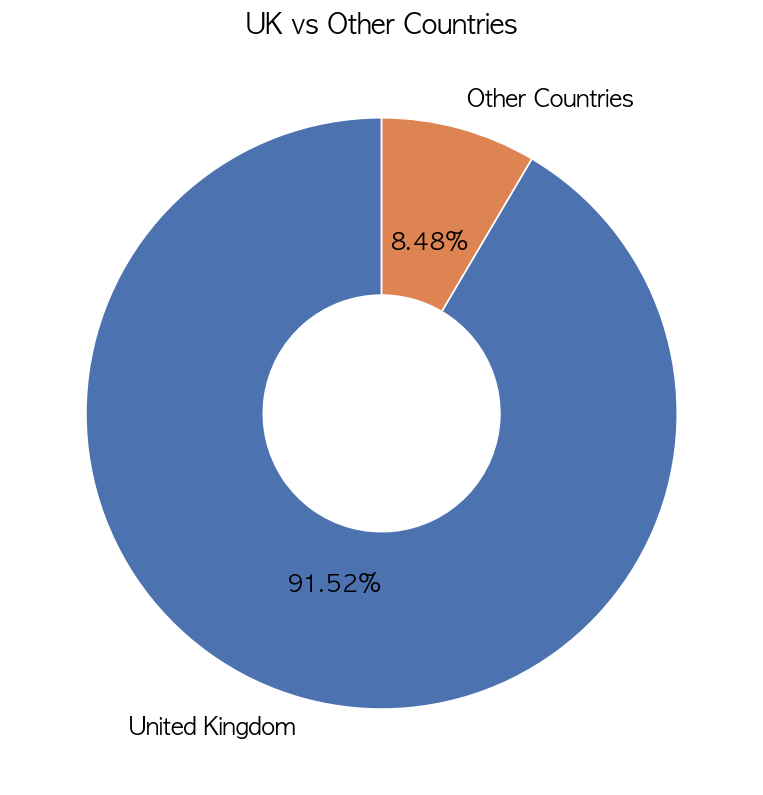

In [145]:
# ==========================================================
# Visualisation — UK vs Other Countries (Donut Chart)
# 시각화 — UK vs 기타 국가 (도넛 차트)
# ==========================================================

uk_count = country_count["United Kingdom"]
others_count = len(df_raw) - uk_count

labels = ["United Kingdom", "Other Countries"]
sizes = [uk_count, others_count]
colors = ["#4C72B0", "#DD8452"]

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.2f%%",
    startangle=90,
    textprops={"fontsize": 14},
    wedgeprops={"edgecolor": "white", "width": 0.6},
)
plt.title("UK vs Other Countries", fontsize=16)
plt.show()


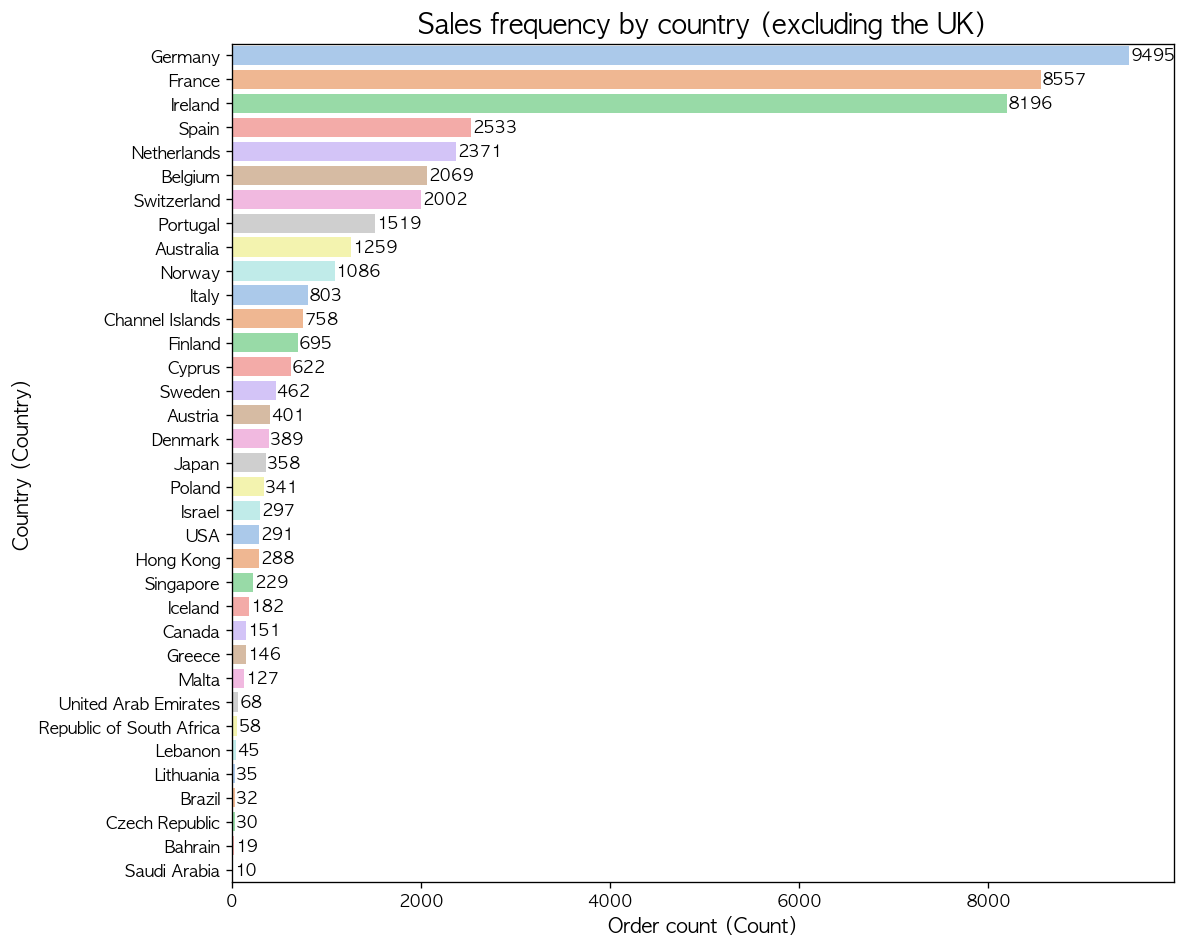

In [146]:
# ==========================================================
# Visualisation — Sales Frequency by Country (Excluding UK)
# 시각화 — UK 제외 국가별 판매 빈도 (막대 차트)
# ==========================================================

plt.figure(figsize=(10, 8))

sns.barplot(
    x=country_count_without_uk.values,
    y=country_count_without_uk.index,
    hue=country_count_without_uk.index,
    palette="pastel",
    legend=False,
)

plt.title("Sales frequency by country (excluding the UK)", fontsize=16)
plt.xlabel("Order count (Count)", fontsize=12)
plt.ylabel("Country (Country)", fontsize=12)

for i, v in enumerate(country_count_without_uk.values):
    plt.text(v + 10, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()


### Observations
### 관찰 결과

> **English** — What did you notice? Is there any data quality issue? Does anything require cleaning?  
> **한국어** — 어떤 점을 발견했는가? 데이터 품질 문제가 있는가? 전처리가 필요한 부분이 있는가?

**Country (국가)**
- United Kingdom accounts for ~91% of transactions, dominating the dataset. Other countries are barely visible in a single chart.  
  UK가 전체 거래의 약 91%를 차지해, 한 차트로는 다른 국가가 거의 보이지 않는다.
- Ambiguous country labels exist: `Unspecified`, `European Community`.  
  `Unspecified`, `European Community`처럼 애매한 국가명이 있다.
- `EIRE` and `RSA` should be renamed to `Ireland` and `Republic of South Africa` for clarity.  
  `EIRE`, `RSA`는 `Ireland`, `Republic of South Africa`로 이름을 정리하는 것이 좋다.

**Quantity (수량)**
- 10,624 rows have `Quantity < 0`; 9,288 rows have `InvoiceNo` starting with `C`. The counts are **not identical**.  
  `Quantity < 0`은 10,624건, `C` 인보이스는 9,288건으로 **개수가 같지 않다**.
- All `C` invoices have negative Quantity; no `C` invoice has positive Quantity.  
  `C` 인보이스는 전부 Quantity가 음수이고, 양수인 `C` 인보이스는 없다.
- 1,336 rows have negative Quantity but **no** `C` prefix — all have `UnitPrice = 0`.  
  Quantity 음수인데 `C`가 아닌 행 1,336건은 **전부 UnitPrice = 0**이다.
- Descriptions in those 1,336 rows include `check`, `damaged`, `damages`, `adjustment`, `amazon`, etc. — internal records, not sales.  
  Description에 `check`, `damaged`, `amazon` 등이 들어 있어 실제 판매가 아니라 내부 기록으로 보인다.

**UnitPrice (단가)**
- 2,515 rows have `UnitPrice = 0`; 2 rows have `UnitPrice < 0` (`Adjust bad debt`, -£11,062.06).  
  `UnitPrice = 0`은 2,515건, `UnitPrice < 0`은 2건(부실채권 조정)이다.
- Among `UnitPrice <= 0` rows: ~50% have `Description` NaN; ~96.6% have `CustomerID` NaN.  
  `UnitPrice <= 0` 행 중 Description NaN 약 50%, CustomerID NaN 약 96.6%다.
- Some `UnitPrice = 0` rows have a Description (`amazon`, `check`, `damaged`) and even a CustomerID (40 rows) — still **£0 revenue**.  
  Description이나 CustomerID가 있어도 UnitPrice=0이면 **매출 £0**이다.
- Filtering `UnitPrice > 0` removes 40 customer-linked rows, but they contribute no revenue (0.007% of total rows).  
  `UnitPrice > 0` 필터 시 CustomerID 있는 40건도 빠지지만, 매출 기여는 0이고 전체의 0.007%에 불과하다.

---

### Cleaning Decisions
### 전처리 결정

- [x] Remove rows where `Quantity <= 0` (cancellations + inventory adjustments, not sales)  
  `Quantity <= 0` 제거 — 취소·재고 조정이며 실제 판매 아님
- [x] Remove rows where `UnitPrice <= 0` (zero-revenue and accounting adjustment records)  
  `UnitPrice <= 0` 제거 — 매출 0 또는 회계 조정 기록
- [x] Create `Revenue = Quantity × UnitPrice` column  
  `Revenue = Quantity × UnitPrice` 컬럼 생성
- [x] Rename countries: `EIRE` → `Ireland`, `RSA` → `Republic of South Africa`  
  국가명 정리: `EIRE` → `Ireland`, `RSA` → `Republic of South Africa`
- [x] Exclude ambiguous countries: `Unspecified`, `European Community`  
  `Unspecified`, `European Community` 제외
- [x] Do **not** remove UK — run Q1 analysis both with and without UK  
  UK는 제거하지 않고, UK 포함/제외 두 버전으로 Q1 분석

---
## 5. Business Question 2 — Sales Trend Analysis
## 매출 추이 분석

### Business Question
**English:** How has monthly revenue trended over time, and what seasonality exists?  
**한국어:** 월별 매출 추이가 어떻게 변해왔으며, 어떤 계절성이 있는가?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `InvoiceDate` | Extract year/month for grouping | 연/월 추출 후 그룹화 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 5-1. Date range and dtype check
**한국어** 날짜 범위 및 dtype 확인

In [147]:
# Date range
# 날짜 범위


#### 5-2. Monthly transaction count — any gaps?
**한국어** 월별 거래 건수 및 누락된 달 확인

In [148]:
# Monthly transaction count
# 월별 거래 건수


#### 5-3. Visualisation placeholder
**한국어** 시각화 자리

In [149]:
# TODO: Line chart — monthly revenue trend


### Observations
### 관찰 결과

> **English** — What did you notice about the trend? Any gaps or anomalies?  
> **한국어** — 추이에서 어떤 점을 발견했는가? 공백이나 이상값이 있는가?

- [ ] &nbsp;
- [ ] &nbsp;

### Cleaning Decisions
### 전처리 결정

- [ ] Convert `InvoiceDate` to datetime if not already
- [ ] Extract `YearMonth` column for grouping
- [ ] &nbsp;

---
## 6. Business Question 3 — Product Performance
## 상품 성과 분석

### Business Question
**English:** Which products generate the most revenue, and do the top 20% of products account for 80% of revenue? (Pareto Principle)  
**한국어:** 어떤 상품이 매출을 가장 많이 만드는가? 상위 20% 상품이 전체 매출의 80%를 차지하는가? (파레토 원칙)

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `Description` | Identify products | 상품 식별 |
| `StockCode` | Identify special/non-product entries | 특수/비상품 항목 식별 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 6-1. Missing Description
**한국어** Description 결측값 확인

In [150]:
# Missing Description count
# Description 결측값 수


#### 6-2. Non-product Description values
**한국어** 비상품 Description 값 확인 (check, damaged, NaN 등)

In [151]:
# Non-product values in Description (e.g. check, damaged, ebay, Manual)
# 비상품 Description 값


#### 6-3. Special StockCodes to exclude
**한국어** 제외할 특수 StockCode (M, POST, AMAZONFEE 등)

In [152]:
# Special StockCodes (M, POST, AMAZONFEE, D, etc.)
# 특수 StockCode 목록


#### 6-4. Top products by frequency
**한국어** 빈도 기준 상위 상품

In [153]:
# Top products by row count (frequency)
# 빈도 기준 상위 상품


#### 6-5. Visualisation placeholder
**한국어** 시각화 자리

In [154]:
# TODO: Horizontal bar chart — top 20 products by revenue
# TODO: Pareto chart — cumulative revenue %


### Observations
### 관찰 결과

> **English** — Are there non-product entries in Description? Does StockCode reveal special records?  
> **한국어** — Description에 비상품 항목이 있는가? StockCode에서 특수 기록이 보이는가?

- [ ] &nbsp;
- [ ] &nbsp;

### Cleaning Decisions
### 전처리 결정

- [ ] Remove rows where `Description` is NaN
- [ ] Remove rows with special StockCodes (`M`, `POST`, `AMAZONFEE`, etc.)
- [ ] &nbsp;

---
## 7. Business Question 4 — Customer Purchase Behavior
## 고객 구매 행동 분석

### Business Question
**English:** How are customer order values distributed, and what portion of revenue comes from large orders?  
**한국어:** 고객 주문 금액 분포가 어떻게 되는가? 대형 주문이 매출에서 차지하는 비중은?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `InvoiceNo` | Identify individual orders | 개별 주문 식별 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 7-1. Cancellations — InvoiceNo starting with 'C'
**한국어** 취소 건 확인 — InvoiceNo가 C로 시작하는 행

In [155]:
# Cancellation count (InvoiceNo starts with 'C')
# 취소 건 수


#### 7-2. Order value per invoice
**한국어** 인보이스별 주문 금액 계산

In [156]:
# Order value = sum of (Quantity × UnitPrice) per InvoiceNo
# 인보이스별 주문 금액


#### 7-3. Descriptive statistics and outliers
**한국어** 기술 통계 및 이상값 확인

In [157]:
# describe() on order values
# 주문 금액 기술 통계


#### 7-4. Visualisation placeholder
**한국어** 시각화 자리

In [158]:
# TODO: Histogram — order value distribution
# TODO: Box plot — order value


### Observations
### 관찰 결과

> **English** — Is the distribution skewed? Are there extreme outliers that need capping?  
> **한국어** — 분포가 한쪽으로 치우쳐있는가? 극단값이 있어 처리가 필요한가?

- [ ] &nbsp;
- [ ] &nbsp;

### Cleaning Decisions
### 전처리 결정

- [ ] Exclude cancelled orders (`InvoiceNo` starting with `'C'`)
- [ ] &nbsp;

---
## 8. Business Question 5 — Customer Value Analysis
## 핵심 고객 분석

### Business Question
**English:** Who are the highest-value customers, and what do their purchase patterns look like?  
**한국어:** 가장 가치 있는 고객은 누구이며, 그들의 구매 패턴은 어떠한가?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `CustomerID` | Identify individual customers | 개별 고객 식별 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |
| `InvoiceDate` | Purchase frequency and recency | 구매 빈도 및 최근성 |

### EDA

#### 8-1. Missing CustomerID
**한국어** CustomerID 결측값 확인

In [159]:
# Missing CustomerID — count and percentage
# CustomerID 결측 수 및 비율


#### 8-2. What are the NaN CustomerID rows?
**한국어** CustomerID NaN 행의 특성 파악 — 게스트 구매인가, 다른 무언가인가?

In [160]:
# Pattern of rows with missing CustomerID
# (check UnitPrice, Quantity, Description patterns)
# CustomerID NaN 행 패턴 확인


#### 8-3. Customer revenue overview (excluding NaN CustomerID)
**한국어** 고객별 매출 개요 (CustomerID NaN 제외)

In [161]:
# Revenue per customer
# 고객별 매출


#### 8-4. Customer purchase frequency
**한국어** 고객별 구매 빈도

In [162]:
# Number of orders per customer
# 고객별 주문 수


#### 8-5. Visualisation placeholder
**한국어** 시각화 자리

In [163]:
# TODO: Bar chart — top 20 customers by revenue
# TODO: Summary table


### Observations
### 관찰 결과

> **English** — What % of rows have no CustomerID? Are they guest purchases or internal records?  
> **한국어** — CustomerID 없는 행이 전체의 몇 %인가? 게스트 구매인가, 내부 기록인가?

- [ ] &nbsp;
- [ ] &nbsp;

### Cleaning Decisions
### 전처리 결정

- [ ] For Q5 specifically, exclude rows where `CustomerID` is NaN
- [ ] &nbsp;

---
## 9. Final Cleaning Decisions
## 최종 전처리 계획

**English**

Summarise all cleaning decisions from EDA into a single reference table.
This table will guide the implementation in `pipeline/clean.py`.

**한국어**

EDA에서 발견한 모든 전처리 결정을 하나의 참조 테이블로 정리한다.
이 테이블은 `pipeline/clean.py` 구현의 기준이 된다.

| Issue | Decision | Pipeline Function |
|-------|----------|-------------------|
| Negative `Quantity` | Remove cancelled transactions | `remove_cancelled()` |
| Negative `UnitPrice` | Remove invalid prices | `remove_invalid_prices()` |
| Revenue | Create `Revenue = Quantity × UnitPrice` | `create_revenue()` |
| `InvoiceDate` | Convert to datetime | `convert_datetime()` |
| `Description` NaN | Remove rows with no product name | `remove_missing_description()` |
| Special `StockCode` | Remove non-product entries | `remove_special_stockcodes()` |
| `CustomerID` NaN | Exclude only for customer-level analysis (Q5) | `filter_known_customers()` |
| | | |
| | | |

> **Notes (참고사항):**
> - Add rows as new decisions are made during EDA.
> - 새로운 전처리 결정이 생기면 행을 추가한다.

---
## 10. Pipeline Implementation Plan
## Pipeline 구현 계획

**English**

Once EDA is complete and all cleaning decisions are validated in this notebook,
the logic will be moved into the `pipeline/` package as reusable, testable functions.

**한국어**

EDA가 완료되고 모든 전처리 결정이 노트북에서 검증되면,
해당 로직은 `pipeline/` 패키지의 재사용 가능하고 테스트 가능한 함수로 이동된다.

---

```
Notebook (실험)
        ↓
Experiment & Observe (탐색 및 관찰)
        ↓
Cleaning Decision (전처리 결정)
        ↓
Pipeline Function (함수로 구현)
        ↓
Reusable, Testable Code (재사용 가능한 코드)
```

---

### File Responsibilities
### 파일별 역할

| File | Responsibility | 역할 |
|------|---------------|------|
| `pipeline/load.py` | Load raw data | 원본 데이터 로드 |
| `pipeline/clean.py` | Apply all cleaning rules | 전처리 규칙 적용 |
| `pipeline/analyze.py` | Answer business questions | 비즈니스 질문에 답 |
| `pipeline/visualize.py` | Produce charts | 차트 생성 |
| `main.py` | Orchestrate the full pipeline | 전체 파이프라인 실행 |